In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [52]:
tickers = ['DODGX',
'CGBL',
'CGGO',
'CGGR',
'JEPI',
'JEPQ',
'JHQDX',
'PRGFX',
'QQQ',
'RSP',
'SPY',
'VIG',
'VV',
'XLE']


In [60]:
close = pd.DataFrame()
ret = pd.DataFrame()

In [61]:
for t in tickers:
    tobj = yf.Ticker(t)
    hist = tobj.history(period='5y', interval="1mo")

    ts = hist['Close']
    print(t, ts.index[0])
    
    close[t] = hist['Close']
    ret[t] = (close[t].shift(-1) - close[t]) / close[t]

DODGX 2021-01-01 00:00:00-05:00
CGBL 2023-10-01 00:00:00-04:00
CGGO 2022-03-01 00:00:00-05:00
CGGR 2022-03-01 00:00:00-05:00
JEPI 2021-01-01 00:00:00-05:00
JEPQ 2022-06-01 00:00:00-04:00
JHQDX 2021-03-01 00:00:00-05:00
PRGFX 2021-01-01 00:00:00-05:00
QQQ 2021-01-01 00:00:00-05:00
RSP 2021-01-01 00:00:00-05:00
SPY 2021-01-01 00:00:00-05:00
VIG 2021-01-01 00:00:00-05:00
VV 2021-01-01 00:00:00-05:00
XLE 2021-01-01 00:00:00-05:00


In [64]:
ret

,DODGX,CGBL,CGGO,CGGR,JEPI,JEPQ,JHQDX,PRGFX,QQQ,RSP,SPY,VIG,VV,XLE
Date,,,,,,,,,,,,,,
2021-01-01 00:00:00-05:00,0.095253,NaN,NaN,NaN,0.002005,NaN,NaN,0.021491,-0.001335,0.060870,0.027805,0.015761,0.025997,0.224567
2021-02-01 00:00:00-05:00,0.049088,NaN,NaN,NaN,0.062397,NaN,NaN,0.000705,0.015885,0.055589,0.041987,0.056533,0.036470,0.018900
2021-03-01 00:00:00-05:00,0.072425,NaN,NaN,NaN,0.025776,NaN,0.017015,0.069208,0.060436,0.051564,0.056359,0.044035,0.057268,0.017408
2021-04-01 00:00:00-04:00,0.033932,NaN,NaN,NaN,0.017226,NaN,0.004470,-0.014865,-0.012012,0.019153,0.006566,0.017581,0.004712,0.057097
2021-05-01 00:00:00-04:00,-0.004905,NaN,NaN,NaN,0.017097,NaN,0.015893,0.069907,0.061390,-0.002581,0.019093,-0.005845,0.023295,0.031795
2021-06-01 00:00:00-04:00,-0.003568,NaN,NaN,NaN,0.024353,NaN,0.015221,0.018299,0.029803,0.015846,0.027764,0.036500,0.026796,-0.073793
2021-07-01 00:00:00-04:00,0.030042,NaN,NaN,NaN,0.019774,NaN,0.011721,0.029628,0.042187,0.023710,0.029760,0.016717,0.029249,-0.020044
2021-08-01 00:00:00-04:00,-0.037363,NaN,NaN,NaN,-0.042711,NaN,-0.026829,-0.054231,-0.057876,-0.041459,-0.049650,-0.054129,-0.049979,0.076240
2021-09-01 00:00:00-04:00,0.046746,NaN,NaN,NaN,0.045426,NaN,0.048407,0.057701,0.079836,0.056843,0.073592,0.074082,0.073853,0.116687


Drop CGBL, too little history

In [65]:
ret = ret.drop(columns=['CGBL'])

Select rows starting with 2022-06-01 and dropping the last row full of NaNs

In [77]:
# can just use a slice
df = ret['2022-06-01':'2025-11-01']

In [78]:
df.corr()

,DODGX,CGGO,CGGR,JEPI,JEPQ,JHQDX,PRGFX,QQQ,RSP,SPY,VIG,VV,XLE
DODGX,1.000000,0.728153,0.717703,0.848714,0.660612,0.701797,0.766275,0.575530,0.850838,0.764041,0.814370,0.766168,0.621765
CGGO,0.728153,1.000000,0.897082,0.838982,0.881608,0.712235,0.805858,0.869594,0.857802,0.935649,0.873723,0.933107,0.400804
CGGR,0.717703,0.897082,1.000000,0.757674,0.911413,0.765775,0.881164,0.932269,0.833668,0.939625,0.806182,0.947481,0.329212
JEPI,0.848714,0.838982,0.757674,1.000000,0.788267,0.618584,0.735185,0.681512,0.911011,0.889873,0.956409,0.883993,0.680313
JEPQ,0.660612,0.881608,0.911413,0.788267,1.000000,0.769559,0.902867,0.950725,0.735415,0.917807,0.774364,0.921471,0.339415
JHQDX,0.701797,0.712235,0.765775,0.618584,0.769559,1.000000,0.804963,0.743901,0.650256,0.710634,0.584217,0.716012,0.271066
PRGFX,0.766275,0.805858,0.881164,0.735185,0.902867,0.804963,1.000000,0.862879,0.679414,0.830542,0.693613,0.841229,0.302849
QQQ,0.575530,0.869594,0.932269,0.681512,0.950725,0.743901,0.862879,1.000000,0.710880,0.907798,0.727656,0.913349,0.234440
RSP,0.850838,0.857802,0.833668,0.911011,0.735415,0.650256,0.679414,0.710880,1.000000,0.917497,0.957398,0.912558,0.659540
SPY,0.764041,0.935649,0.939625,0.889873,0.917807,0.710634,0.830542,0.907798,0.917497,1.000000,0.937358,0.999343,0.529612


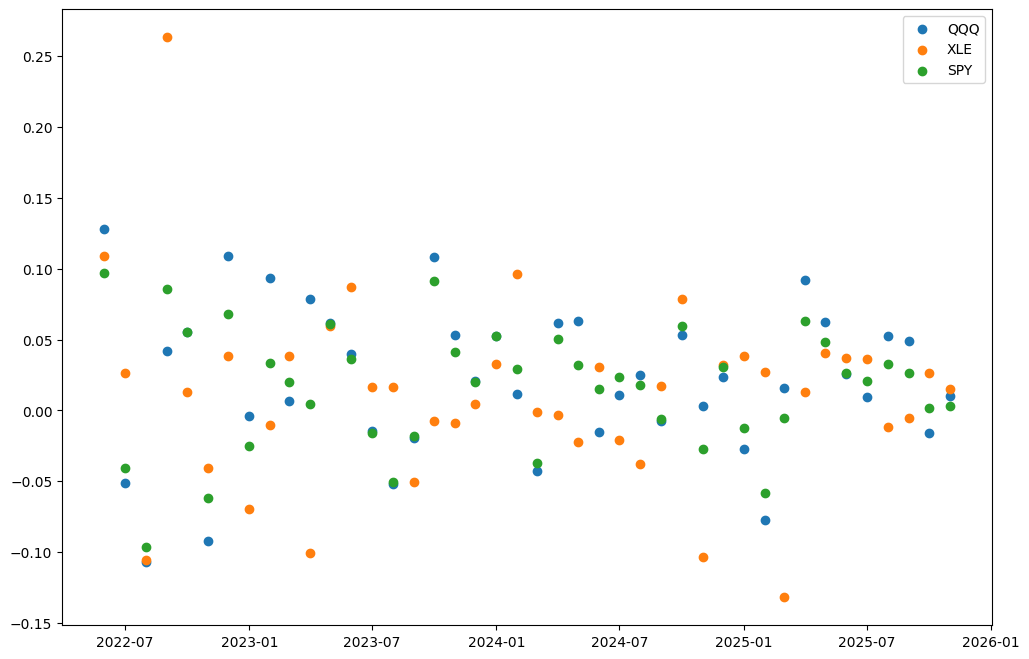

In [93]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(df.index, 'QQQ', data=df)
ax.scatter(df.index, 'XLE', data=df)
ax.scatter(df.index, 'SPY', data=df)
plt.legend()
plt.show()